In [1]:
import warnings
warnings.simplefilter(action='ignore', category=Warning)
import os, sys
# to avoid any possible jupyter crashes due to rpy2 not finding the R install on conda
os.environ['R_HOME'] = sys.exec_prefix+"/lib/R/"

In [2]:
import scanpy as sc
import scFates as scf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

import kktk

In [3]:
import session_info
session_info.show()

In [4]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/tissueaxis.py")
tissueaxis = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = tissueaxis
spec.loader.exec_module(tissueaxis)

In [5]:
sc.settings.set_figure_params(dpi=80)

# Function

# Variables

In [6]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'
celltype = 'SinoatrialNodePacemakerCells'
adata_path = f'{data_object_dir}/b2c_cells_{celltype}_lognorm.h5ad'
celltype_key = 'fine_grain2'

In [7]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'

In [8]:
!ls {data_object_dir}

b2c_cells_AtrialCardiomyocytes_lognorm.h5ad
b2c_cells_EndothelialCells_lognorm.h5ad
b2c_cells_EndothelialCells_raw.h5ad
b2c_cells_EpicardialCells_lognorm.h5ad
b2c_cells_EpicardialCells_raw.h5ad
b2c_cells_LymphoidCells_lognorm.h5ad
b2c_cells_LymphoidCells_raw.h5ad
b2c_cells_MesenchymalCells_lognorm.h5ad
b2c_cells_MesenchymalCells_raw.h5ad
b2c_cells_MyeloidCells_lognorm.h5ad
b2c_cells_MyeloidCells_raw.h5ad
b2c_cells_NeuralCells_lognorm.h5ad
b2c_cells_NeuralCells_raw.h5ad
b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad
b2c_cells_VentricularCardiomyocytes_lognorm.h5ad
b2c_cells_VentricularCardiomyocytes_raw.h5ad
scVI


# Read in data

In [8]:
# read in aCM annotated data
adata = sc.read_h5ad(adata_path)
print(adata.X.data[:5])
adata

[2.22104167 2.22104167 2.22104167 2.22104167 2.22104167]


AnnData object with n_obs × n_vars = 3380 × 17854
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0', 'fine_grain', 'fine_grain2', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_1.0', 'leiden_1.2', 'leiden_1.5', 'leiden_2.0', 

In [9]:
# add short version of the cell type labels
adata.obs[f'{celltype_key}_short'] = adata.obs[celltype_key].astype('str').copy()
df = pd.read_csv('/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/finegrain_name_mapping.csv')
celltype_mapping = df.set_index('Full_name')['Short_name_finalised'].to_dict()
adata.obs.replace({f'{celltype_key}_short':celltype_mapping},inplace=True)
set(adata.obs[f'{celltype_key}_short'])

{'SANPCHd', 'SANPCTl', 'SHPC'}

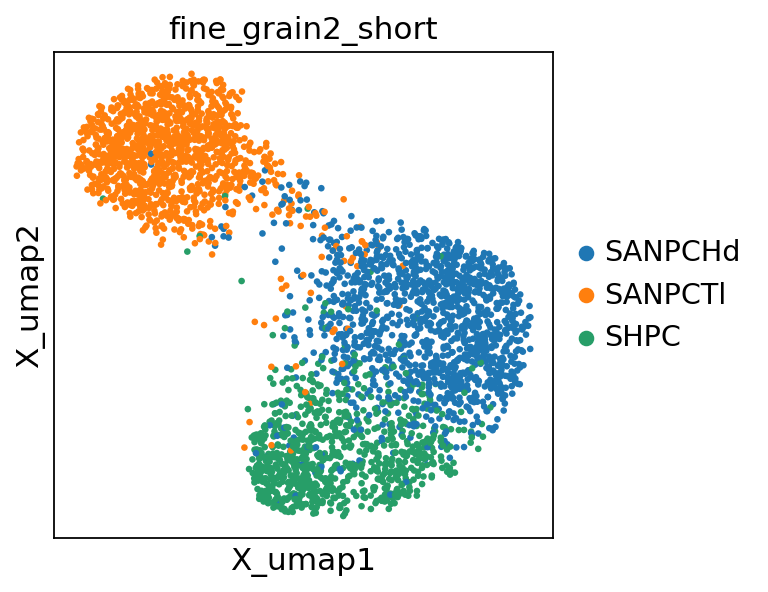

In [10]:
sc.pl.embedding(adata,basis='X_umap',
                color=f'{celltype_key}_short')

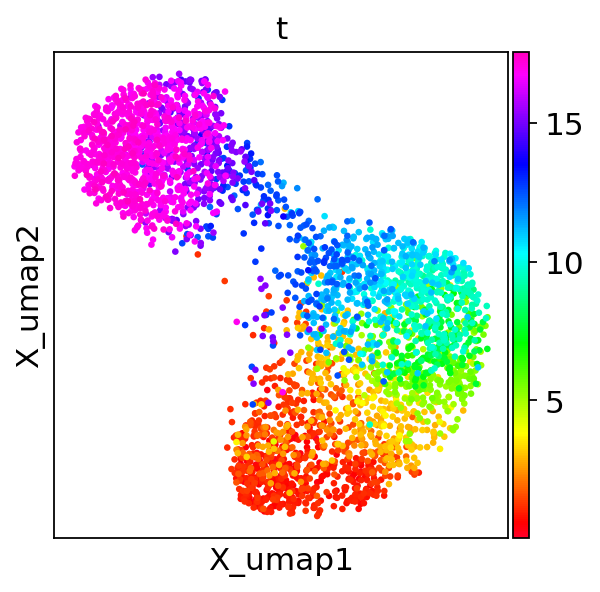

In [12]:
sc.pl.embedding(adata,basis='X_umap',
                color='t',cmap='gist_rainbow')

# Significantly changing feature along pseudotime test

In [11]:
print(adata.X.data[:10])

[2.22104167 2.22104167 2.22104167 2.22104167 2.22104167 2.22104167
 2.22104167 2.22104167 2.85841393 2.22104167]


In [12]:
%%time
scf.tl.test_association(adata,n_jobs=20)

test features for association with the trajectory
    single mapping : 100%|██████████| 17854/17854 [13:38<00:00, 21.83it/s]
    found 82 significant features (0:13:38) --> added
    .var['p_val'] values from statistical test.
    .var['fdr'] corrected values from multiple testing.
    .var['st'] proportion of mapping in which feature is significant.
    .var['A'] amplitue of change of tested feature.
    .var['signi'] feature is significantly changing along pseudotime.
    .uns['stat_assoc_list'] list of fitted features on the graph for all mappings.
CPU times: user 9min 46s, sys: 20.1 s, total: 10min 6s
Wall time: 13min 41s


In [14]:
adata.var

,gene_ids,feature_types,genome,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,...,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,p_val,A,fdr,st,signi
SAMD11,ENSG00000187634,Gene Expression,GRCh38,False,13492,0.014410,0.014307,98.799092,16189.0,9.692149,...,0.286035,2.078713,0.204344,1,False,7.761602e-24,0.266405,1.385756e-19,0,False
NOC2L,ENSG00000188976,Gene Expression,GRCh38,False,16660,0.015533,0.015414,98.517112,17451.0,9.767210,...,0.380541,1.959846,-0.459631,0,False,3.596852e-01,0.051290,1.000000e+00,0,False
KLHL17,ENSG00000187961,Gene Expression,GRCh38,False,3314,0.003005,0.003000,99.705024,3376.0,8.124743,...,0.085971,2.131341,0.751696,1,False,1.211605e-01,0.024059,1.000000e+00,0,False
PLEKHN1,ENSG00000187583,Gene Expression,GRCh38,False,100,0.000089,0.000089,99.991099,100.0,4.615121,...,0.001999,0.909585,-1.216836,0,False,3.378983e-01,0.002843,1.000000e+00,0,False
PERM1,ENSG00000187642,Gene Expression,GRCh38,False,138,0.000123,0.000123,99.987717,138.0,4.934474,...,0.000000,0.000000,0.000000,0,False,1.000000e+00,0.000000,1.000000e+00,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,ENSG00000212907,Gene Expression,GRCh38,True,277503,1.529886,0.928174,75.299760,1718801.0,14.357138,...,3.863548,2.481935,0.523696,0,False,3.316760e-33,0.564183,5.921744e-29,0,False
MT-ND4,ENSG00000198886,Gene Expression,GRCh38,True,314820,1.864854,1.052517,71.978214,2095132.0,14.555128,...,4.210404,2.467885,0.357515,0,False,2.233942e-34,0.488857,3.988481e-30,0,False
MT-ND5,ENSG00000198786,Gene Expression,GRCh38,True,150116,0.265542,0.235501,86.638338,298332.0,12.605966,...,2.268287,2.170010,-0.154984,0,False,2.023862e-18,0.723545,3.613403e-14,0,False
MT-ND6,ENSG00000198695,Gene Expression,GRCh38,True,66055,0.077088,0.074261,94.120516,86607.0,11.369147,...,1.406170,2.052737,-0.148105,0,False,3.104855e-05,0.354100,5.543409e-01,0,False


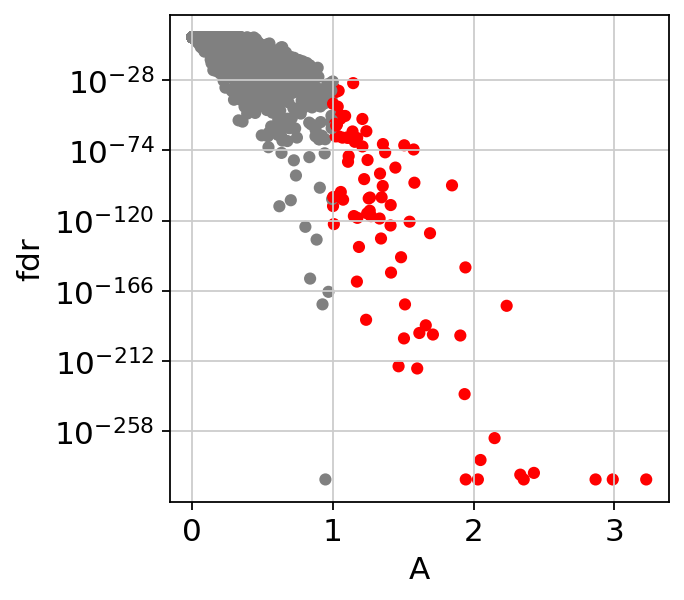

In [15]:
scf.pl.test_association(adata)

In [16]:
fdr_thresh = 0.1
A_thresh = 1

df = adata.var.copy()
df[(df['A']>A_thresh)&(df['fdr']<=fdr_thresh)]

,gene_ids,feature_types,genome,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,...,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,p_val,A,fdr,st,signi
NPPA,ENSG00000175206,Gene Expression,GRCh38,False,209970,2.377829,1.217233,81.310799,2671450.0,14.798132,...,4.996923,4.987373,0.804738,0,False,0.000000e+00,3.228052,0.000000e+00,1,True
NPPB,ENSG00000120937,Gene Expression,GRCh38,False,54985,0.136573,0.128018,95.105845,153438.0,11.941058,...,1.971385,3.579415,6.205010,3,True,0.000000e+00,2.356904,0.000000e+00,1,True
FABP3,ENSG00000121769,Gene Expression,GRCh38,False,137325,0.370842,0.315425,87.776851,416635.0,12.939968,...,2.402418,2.312212,0.253156,0,False,8.620837e-115,1.410590,1.539164e-110,1,True
SLC2A1,ENSG00000117394,Gene Expression,GRCh38,False,106435,0.180369,0.165827,90.526336,202641.0,12.219196,...,2.264343,2.489447,1.169165,3,True,1.317576e-155,1.942099,2.352399e-151,1,True
WLS,ENSG00000116729,Gene Expression,GRCh38,False,88180,0.106233,0.100961,92.151194,119351.0,11.689832,...,2.043307,2.182593,0.110018,1,False,2.580754e-58,1.053510,4.607677e-54,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MYH7B,ENSG00000078814,Gene Expression,GRCh38,False,74027,0.111246,0.105482,93.410937,124983.0,11.735941,...,1.822110,2.230909,0.558624,2,False,2.020072e-78,1.573793,3.606637e-74,1,True
APP,ENSG00000142192,Gene Expression,GRCh38,False,158231,0.249218,0.222518,85.916031,279992.0,12.542520,...,2.639660,2.325226,0.516479,1,False,8.893453e-63,1.022664,1.587837e-58,1,True
ADAMTS1,ENSG00000154734,Gene Expression,GRCh38,False,46126,0.052734,0.051391,95.894375,59246.0,10.989470,...,1.225931,2.139126,0.486674,1,False,1.845527e-48,1.000472,3.295003e-44,1,True
COL6A2,ENSG00000142173,Gene Expression,GRCh38,False,151449,0.297848,0.260707,86.519689,334627.0,12.720775,...,1.491668,2.407348,2.410213,3,True,3.140498e-120,1.242941,5.607045e-116,1,True


# Save

In [18]:
adata.write(adata_path)

# Axon guidance genes

In [11]:
# from embryonic/foetal vs adult comparison
axonguidance_genes = ['SEMA3A', 'SLIT2', 'SLIT3', 'EFNB2', 'CXCL12', 'FGF10', 'VEGFC', 'NELL1']
axonguidance_genes = [x for x in axonguidance_genes if x in adata.var_names]
print(len(axonguidance_genes))

8


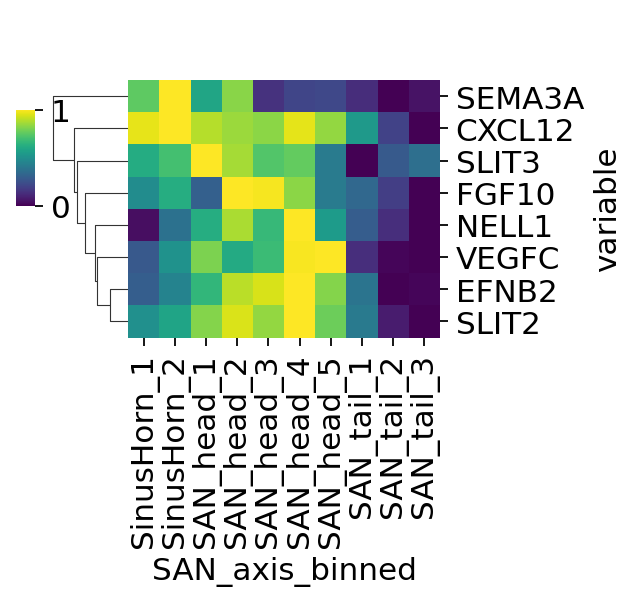

In [11]:
axis_name = 'SAN_axis'
tissueaxis.plot_axis(adata,
              axis_col=axis_name,
              binned_col=f'{axis_name}_bin_annot',
              feature_type='gene', # 'gene' or 'celltype'
              features_to_plot=axonguidance_genes,
              features_to_remove=None,
              threshold_express_prop=0.1, # at quantile=0.9
              threshold_cell_abundance=None, # at quantile=0.9
              correlation=False,
              min_max_scale=True,
              row_cluster=True,
              figsize=(4,4),
              cbar_pos=(-0, 0.65, 0.03, 0.15),
              cmap='viridis',
          xticklabels=True,
          yticklabels=True,
              title=None,
              return_feature = False,
         save=f'{figdir}/VisiumHD_SANaxis_axon-guidance-genes.pdf',
    save_dpi=300,
             )

### Pseudobulk per subpopulation

In [11]:
# check cell number per group
pd.crosstab(adata.obs['donor'],adata.obs[celltype_key])

fine_grain2,SinoatrialNodePacemakerCellsHead,SinoatrialNodePacemakerCellsTail,SinusHornPacemakerCells
donor,,,
BRC2757,502,383,406
BRC2758,122,346,33
C194,695,469,424


In [12]:
adata.obs['celltype_donor'] = adata.obs[f'{celltype_key}_short'].astype('str')+'_'+\
                                     adata.obs['donor'].astype('str')
adata_pb = sc.get.aggregate(adata, by='celltype_donor', 
                            func=["sum"])
adata_pb.X = adata_pb.layers['sum'].copy()

print(adata_pb)
adata_pb.obs[celltype_key] = [x.split('_')[0] for x in adata_pb.obs['celltype_donor']]
adata_pb.obs['donor'] = [x.split('_')[1] for x in adata_pb.obs['celltype_donor']]
adata_pb.obs

AnnData object with n_obs × n_vars = 9 × 17854
    obs: 'celltype_donor'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'p_val', 'A', 'fdr', 'st', 'signi'
    layers: 'sum'


,celltype_donor,fine_grain2,donor
SANPCHd_BRC2757,SANPCHd_BRC2757,SANPCHd,BRC2757
SANPCHd_BRC2758,SANPCHd_BRC2758,SANPCHd,BRC2758
SANPCHd_C194,SANPCHd_C194,SANPCHd,C194
SANPCTl_BRC2757,SANPCTl_BRC2757,SANPCTl,BRC2757
SANPCTl_BRC2758,SANPCTl_BRC2758,SANPCTl,BRC2758
SANPCTl_C194,SANPCTl_C194,SANPCTl,C194
SHPC_BRC2757,SHPC_BRC2757,SHPC,BRC2757
SHPC_BRC2758,SHPC_BRC2758,SHPC,BRC2758
SHPC_C194,SHPC_C194,SHPC,C194


In [13]:
# set category
adata_pb.obs[celltype_key] = pd.Categorical(
    adata_pb.obs[celltype_key],
    categories=['SHPC','SANPCHd','SANPCTl'],
    ordered=True
)

In [14]:
# Log-normalise
sc.pp.filter_genes(adata_pb, min_cells=3)
sc.pp.normalize_total(adata_pb, target_sum=1e4)
sc.pp.log1p(adata_pb)

In [18]:
?kktk.pl.plot_boxplot

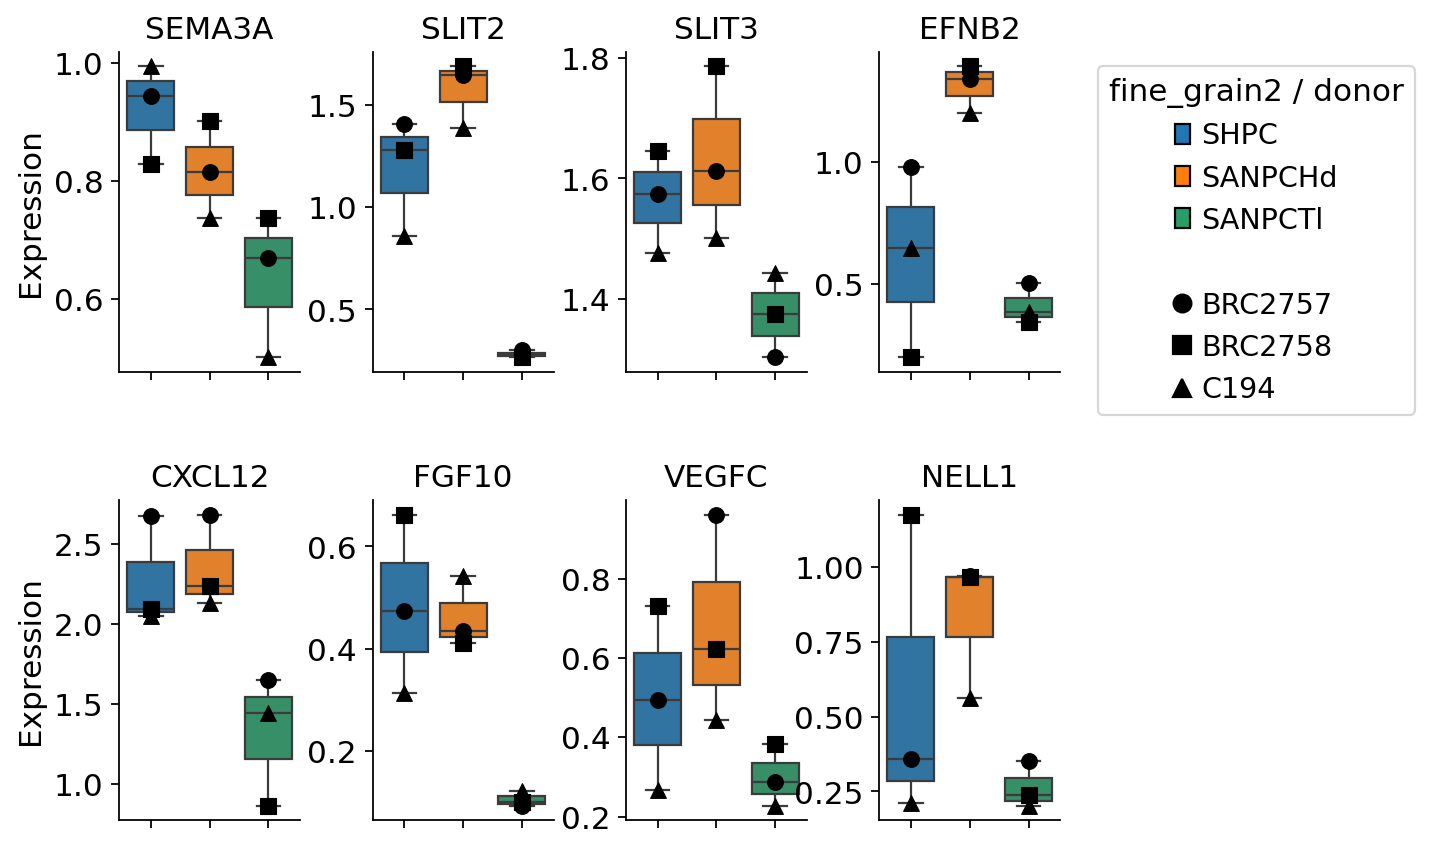

In [17]:
kktk.pl.plot_boxplot(adata_pb, features=axonguidance_genes, 
                     split_col=celltype_key, paired_col='donor', ncols=4, 
                     point_color='black', point_size=50, draw_lines=False,
                     show=False)
plt.savefig(f'{figdir}/VisiumHD_SA-PCs_boxplot_per-axon-guidance-gene.pdf',bbox_inches="tight",dpi=300)

In [19]:
sc.tl.score_genes(adata_pb, axonguidance_genes, score_name='axon_guidance_score')

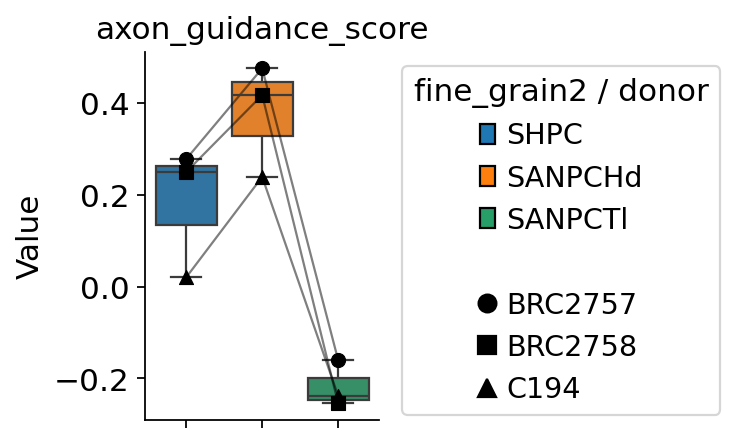

In [26]:
kktk.pl.plot_boxplot(adata_pb, features=['axon_guidance_score'], X_or_obs='obs',
                     split_col=celltype_key, 
                     height=3.5,aspect=0.8,paired_col='donor',
                     point_color='black', point_size=40, 
                     line_color='black', line_width=1, line_alpha=0.5,
                     show=False)
plt.savefig(f'{figdir}/VisiumHD_SA-PCs_boxplot_all-axon-guidance-gene.pdf',bbox_inches="tight",dpi=300)

In [27]:
import statsmodels.formula.api as smf

df = adata_pb.obs[[celltype_key,'donor','axon_guidance_score']]
df['fine_grain2'] = df['fine_grain2'].astype('category')

model = smf.mixedlm(
    "axon_guidance_score ~ fine_grain2",
    df,
    groups=df["donor"]
)
result = model.fit()
print(result.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: axon_guidance_score
No. Observations: 9       Method:             REML               
No. Groups:       3       Scale:              0.0046             
Min. group size:  3       Log-Likelihood:     4.1632             
Max. group size:  3       Converged:          Yes                
Mean group size:  3.0                                            
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.182    0.065  2.819 0.005  0.056  0.309
fine_grain2[T.SANPCHd]  0.195    0.055  3.517 0.000  0.086  0.303
fine_grain2[T.SANPCTl] -0.400    0.055 -7.229 0.000 -0.508 -0.292
Group Var               0.008    0.172                           



/home/kk837/.conda/envs/scfates_env/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


A linear mixed-effects model accounting for donor-level variation indicated higher axon guidance scores in SAN head relative to SAN tail (p<0.001). This difference was consistent across all donors (n=3), supporting a robust spatial gradient.